# *Gephyrocapsa huxleyi* – *Sulfitobacter* D7 Infection Model

## Figures for Jackson Page-Roth's Master's Thesis

### Parameters:
| Symbol | Description |
|--------|-------------|
| **P** | *E. huxleyi* concentration (cells mL-1) |
| **B** | *Sulfitobacter* D7 concentration (cells mL-1) |
| **D** | Dead *E. huxleyi* cells (cells mL-1) |
| **u_P, u_B** | Growth rates (day-1) |
| **k_P, k_B** | Carrying capacities (cells mL-1) |
| **phi_B** | D7 virulence (mL cell-1 day-1) |
| **beta_B** | D7 burst size (cells cell-1) |
| **delta_P** | *E. hux* natural death rate (day-1) |
| **lambda_D** | Dead cell organic dissolution rate (day-1) |
| **x_B** | Dead-cell scaling of phi_B (mL cell-1) |

This notebook covers the bacteria–*E. huxleyi* infection experiment: Bayesian
fitting of the constant-phi and modulated-phi ODE models to the monoculture /
co-culture data (Figures 3 & 4), and the model comparison section.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D
import matplotlib.colors as mcolors
import matplotlib as mpl
import multiprocessing
import warnings
import arviz as az
import pymc as pm
import pytensor.tensor as pt
from pytensor.graph import Apply, Op
from scipy.integrate import solve_ivp
import os

warnings.filterwarnings('ignore', category=RuntimeWarning)
try:
    multiprocessing.set_start_method('fork', force=True)
except ValueError:
    pass

In [2]:
# -- Global settings ----------------------------------------------------------
MODE             = 'medium'  # 'test' | 'medium' | 'publish'
USE_SAVED_TRACES = False       # True  -> load .nc files; False -> run sampler
OVERWRITE_TRACES = False      # True  -> save new traces after sampling

colors = ['#E69F00', '#56B4E9', '#009E73', '#F0E442', '#0072B2', '#D55E00', '#CC79A7', '#000000']

# Figure 3

## Setup — Data, Priors, and Functions

In [ ]:
fp3 = 'data/ehux379_d7.csv'
df3 = pd.read_csv(fp3)
df3 = df3.loc[df3['exp'] == 5]

PRESETS = {
    'test':    (2000,  2000,  4),
    'medium':  (10000, 10000, 4),
    'publish': (50000, 50000, 4),
}
DRAWS, TUNE, CHAINS = PRESETS[MODE]
CORES = 4
print('Mode=%s  Draws=%d  Tune=%d  Chains=%d  Cores=%d'
      % (MODE, DRAWS, TUNE, CHAINS, CORES))

PRIORS_BASE = {
    'mu_P':     (4.4668e-01, 1.0),
    'delta_P':  (7.4131e-02, 1.0),
    'k_P':      (4.3652e+06, 1.0),
    'mu_B':     (4.8978e-01, 1.0),
    'k_B':      (4.3652e+07, 1.0),
    'beta_B':   (4.0500e+00, 1.0),
    'lambda_D': (4.8978e-01, 1.0),
    'P0':       (1.2303e+05, 1.0),
    'B0_mono':  (2.6915e+04, 1.0),
    'B0_co':    (1.3804e+05, 1.0),
    'D_N0':     (8.5114e+03, 1.0),
    'D_B0':     (1.0715e+04, 1.0),
}
PRIORS_MOD   = {**PRIORS_BASE, 'rho':         (2.1878e-14, 1.0)}
PRIORS_CONST = {**PRIORS_BASE, 'phi_const': (1.9498e-08, 1.0)}
print('Priors defined.')
print('  Modulated  (%d params): includes rho'         % len(PRIORS_MOD))
print('  Constant   (%d params): includes phi_const' % len(PRIORS_CONST))

Mode=medium  Draws=10000  Tune=10000  Chains=4  Cores=1
Priors defined.
  Modulated  (13 params): includes rho
  Constant   (13 params): includes phi_const


In [4]:
def get_obs_exp(df, exp_id, with_d7):
    subset = df[
        (df['exp'] == exp_id) &
        (df['d7_present'].astype(bool) == bool(with_d7))
    ].copy().sort_values('time').reset_index(drop=True)

    t     = subset['time'].values.astype(float)
    P     = subset['ehux'].values.astype(float)
    B     = subset['bacteria'].values.astype(float)
    D_raw = subset['sytox+'].values.astype(float)

    D_mask   = np.isfinite(D_raw) & (D_raw > 0)
    has_dead = bool(D_mask.any())

    return {'t': t, 'P': P, 'B': B, 'D': D_raw,
            'D_mask': D_mask, 'has_dead': has_dead}

print('get_obs_exp defined.')

get_obs_exp defined.


In [5]:
def ode_rhs(t, y, p, with_d7, phi_mode):
    """
    Right-hand side of the phytoplankton-bacteria ODE system.
    State vector y = [P, B, D_N, D_B]
    phi_mode: 'mod' -> phi = rho * (D_N + D_B)
              'const' -> phi = phi_const
    with_d7: if False, phi is forced to 0 (monoculture)
    """
    P, B, D_N, D_B = np.maximum(y, 0.0)
    D = D_N + D_B
    if with_d7:
        phi = p['rho'] * D if phi_mode == 'mod' else p['phi_const']
    else:
        phi = 0.0
    dP   = p['mu_P']    * P * (1 - P / p['k_P']) - p['delta_P'] * P - phi * P * B
    dB   = p['mu_B']    * B * (1 - B / p['k_B']) + p['beta_B'] * phi * P * B
    dD_N = p['delta_P'] * P                       - p['lambda_D'] * D_N
    dD_B = phi * P * B                            - p['lambda_D'] * D_B
    return [dP, dB, dD_N, dD_B]


def run_ode(params, t_out, with_d7, phi_mode):
    """
    Integrate the ODE. Returns (P, B, D_N, D_B) or None on failure.
    """
    B0 = params['B0_co'] if with_d7 else params['B0_mono']
    y0 = [params['P0'], B0, params['D_N0'], params['D_B0']]
    t_eval = np.unique(t_out)
    t_span = (0.0, float(t_eval.max()) + 0.1)
    for method in ('RK45', 'Radau'):
        try:
            sol = solve_ivp(
                lambda t, y: ode_rhs(t, y, params, with_d7, phi_mode),
                t_span, y0, method=method, t_eval=t_eval,
                rtol=1e-6, atol=1e-9)
            if sol.success and np.all(np.isfinite(sol.y)):
                interp = lambda row: np.interp(t_out, t_eval, row)
                return (np.maximum(interp(sol.y[0]), 1.0),
                        np.maximum(interp(sol.y[1]), 1.0),
                        np.maximum(interp(sol.y[2]), 1.0),
                        np.maximum(interp(sol.y[3]), 1.0))
        except Exception:
            continue
    return None

print('ODE functions defined.')

ODE functions defined.


In [6]:
def ll_log(obs, pred, sigma=0.3, eps=1e-6):
    """Log-likelihood on log10-transformed data."""
    obs  = np.clip(obs,  eps, None)
    pred = np.clip(pred, eps, None)
    r    = np.log10(obs) - np.log10(pred)
    v    = -0.5 * np.sum((r / sigma)**2 + np.log(2 * np.pi * sigma**2))
    return float(v) if np.isfinite(v) else -1e30

print('ll_log defined.')

ALL_ERROR_COMPONENTS = ['ehux_mono', 'ehux_co', 'bacteria_co', 'dead_co']


class EhuxOp(Op):
    """
    PyTensor Op wrapping the ODE log-likelihood.
    phi_mode : 'mod' | 'const'
    error_components : list of components to include in likelihood.
    """
    def __init__(self, phi_mode, priors, obs_m, obs_c, error_components=None):
        self.phi_mode  = phi_mode
        self.priors    = priors
        self.obs_m     = obs_m
        self.obs_c     = obs_c
        self.error_components = (error_components if error_components is not None
                                 else ALL_ERROR_COMPONENTS)

    def make_node(self, theta):
        return Apply(self, [pt.as_tensor_variable(theta)], [pt.dscalar()])

    def perform(self, node, inputs, outputs):
        theta = inputs[0]
        names = list(self.priors.keys())
        obs_m = self.obs_m
        obs_c = self.obs_c
        ec    = self.error_components

        if not np.all(np.isfinite(theta)):
            outputs[0][0] = np.array(-1e30); return

        params = {n: float(v) for n, v in zip(names, theta)}
        if any(params[k] <= 0 for k in names):
            outputs[0][0] = np.array(-1e30); return

        res_m = None
        if 'ehux_mono' in ec:
            res_m = run_ode(params, obs_m['t'], with_d7=False, phi_mode=self.phi_mode)
            if res_m is None:
                outputs[0][0] = np.array(-1e30); return

        res_c = None
        if any(c in ec for c in ('ehux_co', 'bacteria_co', 'dead_co')):
            res_c = run_ode(params, obs_c['t'], with_d7=True, phi_mode=self.phi_mode)
            if res_c is None:
                outputs[0][0] = np.array(-1e30); return

        total = 0.0
        if 'ehux_mono'   in ec: total += ll_log(obs_m['P'], res_m[0])
        if 'ehux_co'     in ec: total += ll_log(obs_c['P'], res_c[0])
        if 'bacteria_co' in ec:
            mask = obs_c['t'] != 0
            total += ll_log(obs_c['B'][mask], res_c[1][mask])
        if 'dead_co' in ec and obs_c['has_dead']:
            mask  = obs_c['D_mask']
            D_tot = res_c[2][mask] + res_c[3][mask]
            total += ll_log(obs_c['D'][mask], D_tot)

        outputs[0][0] = np.array(total)

print('EhuxOp defined.')

ll_log defined.
EhuxOp defined.


In [7]:
def sanitise(trace):
    """Replace non-finite posterior values with NaN."""
    clean = trace.copy()
    for var in clean.posterior.data_vars:
        arr = clean.posterior[var].values.astype(float)
        arr[~np.isfinite(arr)] = np.nan
        clean.posterior[var] = xr.DataArray(
            arr, dims=clean.posterior[var].dims,
            coords=clean.posterior[var].coords)
    return clean


def sample_model(phi_mode, priors, obs_m, obs_c, error_components=None, mode=None):
    """Build and sample the PyMC model."""
    if mode is not None:
        draws, tune, chains = PRESETS[mode]
        cores = CORES
    else:
        draws, tune, chains, cores = DRAWS, TUNE, CHAINS, CORES

    op = EhuxOp(phi_mode, priors, obs_m, obs_c, error_components)
    with pm.Model():
        rvs   = {name: pm.LogNormal(name, mu=np.log(centre), sigma=sigma)
                 for name, (centre, sigma) in priors.items()}
        theta = pt.as_tensor_variable([rvs[n] for n in priors])
        pm.Potential('likelihood', op(theta))
        trace = pm.sample(
            draws=draws, tune=tune, chains=chains, cores=cores,
            step=pm.DEMetropolisZ(),
            progressbar=True, return_inferencedata=True)
    return sanitise(trace)


def compute_confidence_bands(trace, priors, phi_mode, t_dense, n_samples=200, seed=None):
    """
    Draw posterior samples and compute 5/50/95 percentile bands.
    Returns dict with keys: mono_P, co_P, co_B, co_D_N, co_D_B, co_D
    each with _lo, _med, _hi suffixes.
    """
    post  = trace.posterior
    names = list(priors.keys())
    flat  = {n: post[n].values.reshape(-1) for n in names}
    finite_mask = np.ones(len(next(iter(flat.values()))), dtype=bool)
    for v in flat.values():
        finite_mask &= np.isfinite(v)
    finite_idx = np.where(finite_mask)[0]

    rng    = np.random.default_rng(seed)
    n_draw = min(n_samples, len(finite_idx))
    idx    = rng.choice(finite_idx, size=n_draw, replace=False)

    store = {'mono_P': [], 'co_P': [], 'co_B': [], 'co_D_N': [], 'co_D_B': []}
    for i in idx:
        p  = {n: float(flat[n][i]) for n in names}
        rm = run_ode(p, t_dense, with_d7=False, phi_mode=phi_mode)
        rc = run_ode(p, t_dense, with_d7=True,  phi_mode=phi_mode)
        if rm is not None: store['mono_P'].append(rm[0])
        if rc is not None:
            store['co_P'].append(rc[0]); store['co_B'].append(rc[1])
            store['co_D_N'].append(rc[2]); store['co_D_B'].append(rc[3])

    bands = {}
    for key, curves in store.items():
        if not curves: continue
        arr = np.array(curves)
        for pct, suf in zip((5, 50, 95), ('_lo', '_med', '_hi')):
            bands[key + suf] = np.percentile(arr, pct, axis=0)
    if 'co_D_N_lo' in bands and 'co_D_B_lo' in bands:
        for suf in ('_lo', '_med', '_hi'):
            bands['co_D' + suf] = bands['co_D_N' + suf] + bands['co_D_B' + suf]
    return bands

print('sanitise, sample_model, compute_confidence_bands defined.')

def r2_log(obs, pred, eps=1e-6):
    obs  = np.log10(np.clip(obs,  eps, None))
    pred = np.log10(np.clip(pred, eps, None))
    ss_res = np.sum((obs - pred) ** 2)
    ss_tot = np.sum((obs - np.mean(obs)) ** 2)
    return 1 - ss_res / ss_tot

sanitise, sample_model, compute_confidence_bands defined.


In [8]:
import xarray as xr  # needed by sanitise()

obs_m_df3 = get_obs_exp(df3, 5, with_d7=False)
obs_c_df3 = get_obs_exp(df3, 5, with_d7=True)

max_t_df3   = max(obs_m_df3['t'].max(), obs_c_df3['t'].max())
t_dense_df3 = np.linspace(0, max_t_df3, 300)

print('df3 observations extracted.')
print('  Monoculture time points : %d  (t = %s)' % (len(obs_m_df3['t']), obs_m_df3['t']))
print('  Co-culture  time points : %d  (t = %s)' % (len(obs_c_df3['t']), obs_c_df3['t']))
print('  Dead-cell data present  : %s' % obs_c_df3['has_dead'])
print('  Dense grid              : 0 -> %.1f days  (%d points)' % (max_t_df3, len(t_dense_df3)))

df3 observations extracted.
  Monoculture time points : 36  (t = [ 0.  0.  0.  1.  1.  1.  2.  2.  2.  3.  3.  3.  4.  4.  4.  5.  5.  5.
  6.  6.  6.  7.  7.  7.  8.  8.  8.  9.  9.  9. 10. 10. 10. 11. 11. 11.])
  Co-culture  time points : 36  (t = [ 0.  0.  0.  1.  1.  1.  2.  2.  2.  3.  3.  3.  4.  4.  4.  5.  5.  5.
  6.  6.  6.  7.  7.  7.  8.  8.  8.  9.  9.  9. 10. 10. 10. 11. 11. 11.])
  Dead-cell data present  : True
  Dense grid              : 0 -> 11.0 days  (300 points)


## Constant Phi — All Four Error Components

In [9]:
EC_FULL = ['ehux_mono', 'ehux_co', 'bacteria_co', 'dead_co']
TRACE_CONST_PATH = 'data/trace_const.nc'

if USE_SAVED_TRACES and os.path.exists(TRACE_CONST_PATH):
    trace_const_full = az.from_netcdf(TRACE_CONST_PATH)
    print('Loaded trace_const_full from:', TRACE_CONST_PATH)
else:
    trace_const_full = sample_model(
        phi_mode         = 'const',
        priors           = PRIORS_CONST,
        obs_m            = obs_m_df3,
        obs_c            = obs_c_df3,
        error_components = EC_FULL,
    )
    print('Constant phi sampling complete.')
    if OVERWRITE_TRACES:
        trace_const_full.to_netcdf(TRACE_CONST_PATH)
        print('Saved to:', TRACE_CONST_PATH)

Sequential sampling (4 chains in 1 job)
DEMetropolisZ: [mu_P, delta_P, k_P, mu_B, k_B, beta_B, lambda_D, P0, B0_mono, B0_co, D_N0, D_B0, phi_const]


Output()

Sampling 4 chains for 10_000 tune and 10_000 draw iterations (40_000 + 40_000 draws total) took 627 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


Constant phi sampling complete.


In [10]:
param_names_const = list(PRIORS_CONST.keys())
summary_const = az.summary(
    trace_const_full, var_names=param_names_const,
    stat_funcs=None, round_to=10,
)
print('\n' + '='*70)
print('  Constant phi  |  All four error components')
print('='*70)
print(summary_const.to_string())
print('='*70)
print()
print('Parameter comparison: prior centre vs posterior median')
print('  %-12s  %14s  %14s' % ('Parameter', 'Prior centre', 'Post. median'))
print('  ' + '-'*44)
for name in param_names_const:
    centre = PRIORS_CONST[name][0]
    median = float(trace_const_full.posterior[name].median())
    print('  %-12s  %14.4e  %14.4e' % (name, centre, median))


  Constant phi  |  All four error components
                   mean            sd        hdi_3%       hdi_97%     mcse_mean       mcse_sd    ess_bulk     ess_tail     r_hat
mu_P       7.499570e-01  1.053304e-01  5.620339e-01  9.476786e-01  4.870883e-03  3.446385e-03  454.620912  1085.916208  1.006270
delta_P    3.118129e-02  1.437187e-02  7.306641e-03  5.741486e-02  8.665397e-04  6.133870e-04  253.653216   513.587432  1.019510
k_P        6.790630e+06  1.198524e+06  4.842661e+06  9.043902e+06  5.481236e+04  3.977406e+04  570.342131   915.830476  1.012816
mu_B       5.945952e-01  7.310858e-02  4.550156e-01  7.233884e-01  1.206556e-02  8.600352e-03   37.299220   301.821832  1.077527
k_B        5.861714e+08  3.376219e+08  1.896243e+08  1.155351e+09  1.808552e+07  1.279911e+07  350.258859   528.973686  1.024386
beta_B     2.628177e+00  1.697906e+00  3.451599e-01  5.555325e+00  2.656642e-01  1.892109e-01   30.269300   254.941079  1.098118
lambda_D   5.790731e-01  1.488015e-01  3.161983e-01

## Figure 3 — Phi Sweep

In [11]:
# -- User inputs ----------------------------------------------------------------
PHI_MIN = 5e-9
PHI_MAX = 1.75e-8
N_LINES = 5

# Pull posterior medians from trace_const_full
median_params = {name: float(trace_const_full.posterior[name].median())
                 for name in list(PRIORS_CONST.keys())}

PHI_VALUES_SWEEP = np.linspace(PHI_MIN, PHI_MAX, N_LINES)

results_sweep_phi = []
for phi in PHI_VALUES_SWEEP:
    p = {**median_params, 'phi_const': phi}
    sol = run_ode(p, t_dense_df3, with_d7=True, phi_mode='const')
    results_sweep_phi.append(sol)

sol_mono_phi = run_ode(median_params, t_dense_df3, with_d7=False, phi_mode='const')

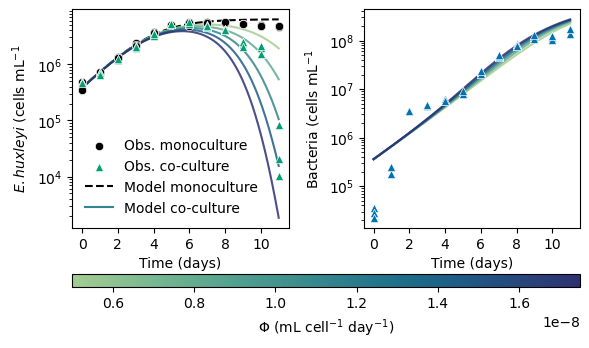

In [12]:
cmap = sns.color_palette("crest", as_cmap=True)
norm = mcolors.Normalize(vmin=PHI_MIN, vmax=PHI_MAX)

fig, ax = plt.subplots(1, 2, figsize=(6, 3.85))

sns.scatterplot(data=obs_m_df3, x='t', y='P', ax=ax[0],
                label='Obs. monoculture', color='black', zorder=2)
sns.scatterplot(data=obs_c_df3, x='t', y='P', ax=ax[0],
                label='Obs. co-culture', marker='^', color=colors[2], zorder=2)
sns.scatterplot(data=obs_c_df3, x='t', y='B', ax=ax[1],
                marker='^', color=colors[4], zorder=2)

if sol_mono_phi is not None:
    P_m, B_m, DN_m, DB_m = sol_mono_phi
    sns.lineplot(x=t_dense_df3, y=P_m, ax=ax[0],
                 color='black', ls='--', label='Model monoculture', zorder=0)

for phi, sol in zip(PHI_VALUES_SWEEP, results_sweep_phi):
    if sol is None: continue
    P_c, B_c, DN_c, DB_c = sol
    color = cmap(norm(phi))
    sns.lineplot(x=t_dense_df3, y=P_c, ax=ax[0], color=color, alpha=0.85, zorder=1)
    sns.lineplot(x=t_dense_df3, y=B_c, ax=ax[1], color=color, alpha=0.85, zorder=1)

sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
handles, labels = ax[0].get_legend_handles_labels()
proxy_co = Line2D([0], [0], color=cmap(norm(np.mean([PHI_MIN, PHI_MAX]))),
                  label='Model co-culture')
ax[0].legend(handles=handles + [proxy_co], labels=labels + ['Model co-culture'],
             loc='lower left', frameon=False)

ax[0].set_xlabel('Time (days)'); ax[1].set_xlabel('Time (days)')
ax[0].set_ylabel(r'$\it{E. huxleyi}$ (cells mL$^{-1}$')
ax[1].set_ylabel('Bacteria (cells mL$^{-1}$')
ax[0].set_yscale('log'); ax[1].set_yscale('log')
ax[0].set_xticks(np.arange(0, 12, 2)); ax[1].set_xticks(np.arange(0, 12, 2))

plt.tight_layout()
cbar = plt.colorbar(sm, ax=ax, label=r'$\Phi$ (mL cell$^{-1}$ day$^{-1}$)',
                    orientation="horizontal", aspect=40, pad=0.15)
# plt.savefig('figures/fig03.pdf', dpi=600, bbox_inches="tight")

# Figure 4 — Modulated Phi

In [13]:
TRACE_MOD_PATH = 'data/trace_mod.nc'

if USE_SAVED_TRACES and os.path.exists(TRACE_MOD_PATH):
    trace_df3_mod = az.from_netcdf(TRACE_MOD_PATH)
    print('Loaded trace_df3_mod from:', TRACE_MOD_PATH)
else:
    trace_df3_mod = sample_model(
        phi_mode         = 'mod',
        priors           = PRIORS_MOD,
        obs_m            = obs_m_df3,
        obs_c            = obs_c_df3,
        error_components = ['ehux_mono', 'ehux_co', 'bacteria_co', 'dead_co'],
    )
    print('Modulated phi sampling complete.')
    if OVERWRITE_TRACES:
        trace_df3_mod.to_netcdf(TRACE_MOD_PATH)
        print('Saved to:', TRACE_MOD_PATH)

Sequential sampling (4 chains in 1 job)
DEMetropolisZ: [mu_P, delta_P, k_P, mu_B, k_B, beta_B, lambda_D, P0, B0_mono, B0_co, D_N0, D_B0, rho]


Output()

Sampling 4 chains for 10_000 tune and 10_000 draw iterations (40_000 + 40_000 draws total) took 591 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


Modulated phi sampling complete.


In [14]:
param_names_mod = list(PRIORS_MOD.keys())
summary_df3_mod = az.summary(
    trace_df3_mod, var_names=param_names_mod,
    stat_funcs=None, round_to=10,
)
print('\n' + '='*70)
print('  df3  |  Modulated phi (x*D)  |  All four error components')
print('='*70)
print(summary_df3_mod.to_string())
print('='*70)

print('\n  Parameter comparison: prior centre vs posterior median')
print('  %-12s  %14s  %14s' % ('Parameter', 'Prior centre', 'Post. median'))
print('  ' + '-'*44)
for name in param_names_mod:
    centre = PRIORS_MOD[name][0]
    median = float(trace_df3_mod.posterior[name].median())
    print('  %-12s  %14.4e  %14.4e' % (name, centre, median))


  df3  |  Modulated phi (x*D)  |  All four error components
                  mean            sd        hdi_3%       hdi_97%     mcse_mean       mcse_sd    ess_bulk     ess_tail     r_hat
mu_P      8.122424e-01  1.260825e-01  5.841500e-01  1.054380e+00  5.273883e-03  3.731104e-03  569.540654  1219.095860  1.015021
delta_P   4.694844e-02  1.313027e-02  2.445451e-02  7.100240e-02  1.076710e-03  7.628472e-04  145.899842   679.653282  1.037743
k_P       5.833163e+06  8.910348e+05  4.320389e+06  7.500418e+06  3.659461e+04  2.588904e+04  562.920475  1212.783939  1.021317
mu_B      6.538749e-01  6.364424e-02  5.287728e-01  7.697555e-01  3.147581e-03  2.227266e-03  408.057975   776.530475  1.010720
k_B       3.164987e+08  2.824150e+08  1.003727e+08  6.070466e+08  1.887885e+07  1.336680e+07  327.148661   289.960001  1.013539
beta_B    2.955357e+00  2.140966e+00  2.092225e-01  6.731906e+00  2.663694e-01  1.892086e-01   72.747198   699.229500  1.053921
lambda_D  2.990999e-01  1.244876e-01  8.069

In [15]:
bands_df3_mod = compute_confidence_bands(
    trace=trace_df3_mod, priors=PRIORS_MOD, phi_mode='mod',
    t_dense=t_dense_df3, n_samples=200, seed=42,
)
D_lo  = bands_df3_mod['co_D_N_lo']  + bands_df3_mod['co_D_B_lo']
D_med = bands_df3_mod['co_D_N_med'] + bands_df3_mod['co_D_B_med']
D_hi  = bands_df3_mod['co_D_N_hi']  + bands_df3_mod['co_D_B_hi']
print('Confidence bands computed.')

Confidence bands computed.


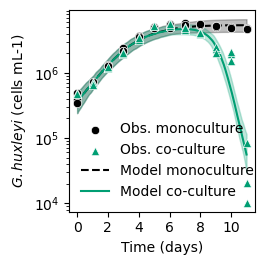

In [16]:
fig, ax = plt.subplots(figsize=(2.75, 2.75))
sns.scatterplot(data=obs_m_df3, x='t', y='P',
                color=colors[7], zorder=5, marker='o', ax=ax, label='Obs. monoculture')
sns.scatterplot(data=obs_c_df3, x='t', y='P',
                color=colors[2], zorder=5, marker='^', ax=ax, label='Obs. co-culture')
sns.lineplot(x=t_dense_df3, y=bands_df3_mod['mono_P_med'],
             ax=ax, color='black', ls='--', label='Model monoculture')
sns.lineplot(x=t_dense_df3, y=bands_df3_mod['co_P_med'],
             ax=ax, color=colors[2], label='Model co-culture')
ax.fill_between(t_dense_df3, bands_df3_mod['mono_P_lo'], bands_df3_mod['mono_P_hi'],
                alpha=0.25, color=colors[7])
ax.fill_between(t_dense_df3, bands_df3_mod['co_P_lo'], bands_df3_mod['co_P_hi'],
                alpha=0.25, color=colors[2])
ax.set_xlabel('Time (days)')
ax.set_ylabel(r'$\it{G. huxleyi}$ (cells mL-1)')
ax.set_yscale('log')
ax.legend(frameon=False, loc='lower left')
ax.set_xticks(np.arange(0, 12, 2))
plt.tight_layout()
# plt.savefig('figures/fig04a.pdf', dpi=600, bbox_inches="tight")
plt.show()

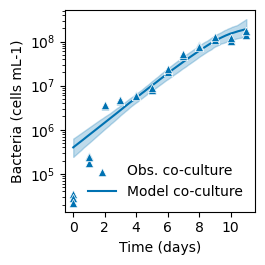

In [17]:
fig, ax = plt.subplots(figsize=(2.75, 2.75))
sns.scatterplot(data=obs_c_df3, x='t', y='B',
                color=colors[4], zorder=5, marker='^', ax=ax, label='Obs. co-culture')
sns.lineplot(x=t_dense_df3, y=bands_df3_mod['co_B_med'],
             ax=ax, color=colors[4], label='Model co-culture')
ax.fill_between(t_dense_df3, bands_df3_mod['co_B_lo'], bands_df3_mod['co_B_hi'],
                alpha=0.25, color=colors[4])
ax.set_xlabel('Time (days)')
ax.set_ylabel('Bacteria (cells mL-1)')
ax.set_yscale('log')
ax.legend(frameon=False, loc='lower right')
ax.set_xticks(np.arange(0, 12, 2))
plt.tight_layout()
# plt.savefig('figures/fig04b.pdf', dpi=600, bbox_inches="tight")
plt.show()

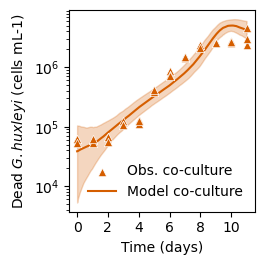

In [18]:
fig, ax = plt.subplots(figsize=(2.75, 2.75))
sns.scatterplot(data=obs_c_df3, x='t', y='D',
                color=colors[5], zorder=5, marker='^', ax=ax, label='Obs. co-culture')
sns.lineplot(x=t_dense_df3, y=D_med, ax=ax, color=colors[5], label='Model co-culture')
ax.fill_between(t_dense_df3, D_lo, D_hi, alpha=0.25, color=colors[5])
ax.set_xlabel('Time (days)')
ax.set_ylabel(r'Dead $\it{G. huxleyi}$ (cells mL-1)')
ax.set_yscale('log')
ax.legend(frameon=False, loc='lower right')
ax.set_xticks(np.arange(0, 12, 2))
plt.tight_layout()
# plt.savefig('figures/fig04c.pdf', dpi=600, bbox_inches="tight")
plt.show()

# Model Comparison

In [19]:
def compute_loglik_samples(trace, priors, phi_mode, obs_m, obs_c,
                            error_components, n_samples=500, seed=42):
    """Evaluate the total log-likelihood at n_samples posterior draws."""
    post  = trace.posterior
    names = list(priors.keys())
    flat  = {n: post[n].values.reshape(-1) for n in names}
    finite_mask = np.ones(len(next(iter(flat.values()))), dtype=bool)
    for v in flat.values():
        finite_mask &= np.isfinite(v)
    finite_idx = np.where(finite_mask)[0]

    rng = np.random.default_rng(seed)
    idx = rng.choice(finite_idx, size=min(n_samples, len(finite_idx)), replace=False)

    ec = error_components
    logliks = []
    for i in idx:
        params = {n: float(flat[n][i]) for n in names}
        res_m, res_c = None, None
        if 'ehux_mono' in ec:
            res_m = run_ode(params, obs_m['t'], with_d7=False, phi_mode=phi_mode)
        if any(c in ec for c in ('ehux_co', 'bacteria_co', 'dead_co')):
            res_c = run_ode(params, obs_c['t'], with_d7=True, phi_mode=phi_mode)
        if (('ehux_mono' in ec and res_m is None) or
            (any(c in ec for c in ('ehux_co', 'bacteria_co', 'dead_co')) and res_c is None)):
            continue
        total = 0.0
        if 'ehux_mono'   in ec: total += ll_log(obs_m['P'], res_m[0])
        if 'ehux_co'     in ec: total += ll_log(obs_c['P'], res_c[0])
        if 'bacteria_co' in ec:
            mask = obs_c['t'] != 0
            total += ll_log(obs_c['B'][mask], res_c[1][mask])
        if 'dead_co' in ec and obs_c['has_dead']:
            mask  = obs_c['D_mask']
            D_tot = res_c[2][mask] + res_c[3][mask]
            total += ll_log(obs_c['D'][mask], D_tot)
        logliks.append(total)
    return np.array(logliks)


ll_const = compute_loglik_samples(
    trace_const_full, PRIORS_CONST, 'const',
    obs_m_df3, obs_c_df3, EC_FULL, n_samples=500, seed=42)

ll_mod = compute_loglik_samples(
    trace_df3_mod, PRIORS_MOD, 'mod',
    obs_m_df3, obs_c_df3, EC_FULL, n_samples=500, seed=42)

print('Log-likelihoods computed.')
print('  Constant phi  -- mean: %.2f   median: %.2f   SD: %.2f'
      % (ll_const.mean(), np.median(ll_const), ll_const.std()))
print('  Modulated phi -- mean: %.2f   median: %.2f   SD: %.2f'
      % (ll_mod.mean(), np.median(ll_mod), ll_mod.std()))
print('  Delta median (mod - const): %.2f' % (np.median(ll_mod) - np.median(ll_const)))

Log-likelihoods computed.
  Constant phi  -- mean: 8.82   median: 9.10   SD: 2.54
  Modulated phi -- mean: 9.83   median: 10.13   SD: 2.31
  Delta median (mod - const): 1.03


/var/folders/mp/cspgvq_d2h13_l03bp7hsr0r0000gn/T/ipykernel_37098/1549525995.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=ll_df, x='Model', y='Log-likelihood',


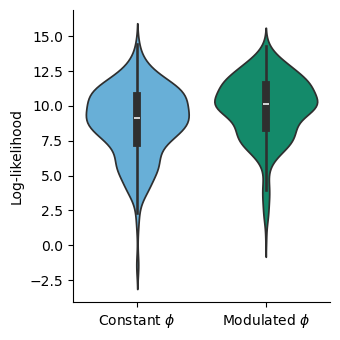

In [20]:
ll_df = pd.DataFrame({
    'Log-likelihood': np.concatenate([ll_const, ll_mod]),
    'Model': ([r'Constant $\phi$'] * len(ll_const) +
              [r'Modulated $\phi$'] * len(ll_mod)),
})
fig, ax = plt.subplots(figsize=(3.5, 3.5))
sns.violinplot(data=ll_df, x='Model', y='Log-likelihood',
               palette=[colors[1], colors[2]], inner='box', ax=ax)
ax.set_xlabel('')
ax.set_ylabel('Log-likelihood')
sns.despine()
plt.tight_layout()
# plt.savefig('figures/model_comparison.pdf', dpi=600, bbox_inches='tight')
plt.show()

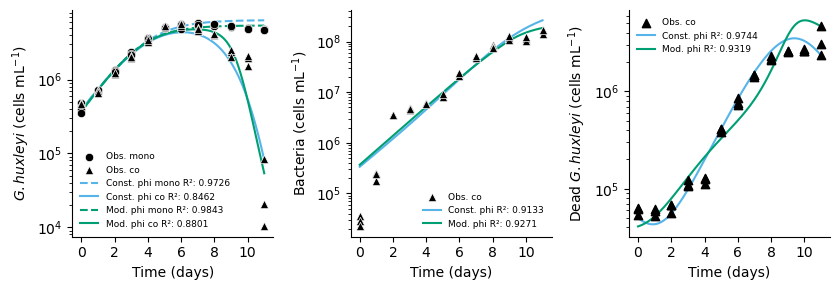

In [30]:
# Publish-level posterior medians -- from trace_const_full and trace_df3_mod
params_const = {
    'mu_P':      7.3671e-01, 'delta_P':   2.7818e-02, 'k_P':       6.6351e+06,
    'mu_B':      6.2220e-01, 'k_B':       5.0028e+08, 'beta_B':    1.7687e+00,
    'lambda_D':  5.5567e-01, 'P0':        3.8864e+05, 'B0_mono':   2.7456e+04,
    'B0_co':     3.3608e+05, 'D_N0':      1.9984e+04, 'D_B0':      3.0045e+04,
    'phi_const': 1.1538e-08,
}
params_mod = {
    'mu_P':     8.0456e-01, 'delta_P':  4.3287e-02, 'k_P':      5.7045e+06,
    'mu_B':     6.6355e-01, 'k_B':      2.4397e+08, 'beta_B':   2.3001e+00,
    'lambda_D': 2.6258e-01, 'P0':       3.6569e+05, 'B0_mono':  2.6683e+04,
    'B0_co':    3.6759e+05, 'D_N0':     1.6927e+04, 'D_B0':     2.4086e+04,
    'rho':        3.5029e-15,
}

sol_const_mono = run_ode(params_const, t_dense_df3, with_d7=False, phi_mode='const')
sol_const_co   = run_ode(params_const, t_dense_df3, with_d7=True,  phi_mode='const')
sol_mod_mono   = run_ode(params_mod,   t_dense_df3, with_d7=False, phi_mode='mod')
sol_mod_co     = run_ode(params_mod,   t_dense_df3, with_d7=True,  phi_mode='mod')

COLOR_CONST = colors[1]
COLOR_MOD   = colors[2]
COLOR_OBS   = colors[7]

fig, axes = plt.subplots(1, 3, figsize=(8.5, 3.0))

ax = axes[0]
sns.scatterplot(data=obs_m_df3, x='t', y='P', color=COLOR_OBS, marker='o', ax=ax, label='Obs. mono', zorder=5)
sns.scatterplot(data=obs_c_df3, x='t', y='P', color=COLOR_OBS, marker='^', ax=ax, label='Obs. co', zorder=5)
if sol_const_mono is not None:
    ax.plot(t_dense_df3, sol_const_mono[0], color=COLOR_CONST, ls='--', label='Const. phi mono R²: 0.9726')
if sol_const_co is not None:
    ax.plot(t_dense_df3, sol_const_co[0],   color=COLOR_CONST,           label='Const. phi co R²: 0.8462')
if sol_mod_mono is not None:
    ax.plot(t_dense_df3, sol_mod_mono[0],   color=COLOR_MOD,   ls='--', label='Mod. phi mono R²: 0.9843')
if sol_mod_co is not None:
    ax.plot(t_dense_df3, sol_mod_co[0],     color=COLOR_MOD,             label='Mod. phi co R²: 0.8801')
ax.set_yscale('log'); ax.set_xlabel('Time (days)')
ax.set_ylabel(r'$\it{G. huxleyi}$ (cells mL$^{-1}$)')
ax.set_xticks(np.arange(0, max_t_df3 + 1, 2))
ax.legend(frameon=False, fontsize=6.5)

ax = axes[1]
sns.scatterplot(data=obs_c_df3, x='t', y='B', color=COLOR_OBS, marker='^', ax=ax, label='Obs. co', zorder=5)
if sol_const_co is not None:
    ax.plot(t_dense_df3, sol_const_co[1], color=COLOR_CONST, label='Const. phi R²: 0.9133')
if sol_mod_co is not None:
    ax.plot(t_dense_df3, sol_mod_co[1],   color=COLOR_MOD,   label='Mod. phi R²: 0.9271')
ax.set_yscale('log'); ax.set_xlabel('Time (days)')
ax.set_ylabel('Bacteria (cells mL$^{-1}$)')
ax.set_xticks(np.arange(0, max_t_df3 + 1, 2))
ax.legend(frameon=False, fontsize=6.5)

ax = axes[2]
if obs_c_df3['has_dead']:
    mask = obs_c_df3['D_mask']
    ax.scatter(obs_c_df3['t'][mask], obs_c_df3['D'][mask],
               color=COLOR_OBS, marker='^', label='Obs. co', zorder=5)
if sol_const_co is not None:
    ax.plot(t_dense_df3, sol_const_co[2] + sol_const_co[3], color=COLOR_CONST, label='Const. phi R²: 0.9744')
if sol_mod_co is not None:
    ax.plot(t_dense_df3, sol_mod_co[2] + sol_mod_co[3],     color=COLOR_MOD,   label='Mod. phi R²: 0.9319')
ax.set_yscale('log'); ax.set_xlabel('Time (days)')
ax.set_ylabel(r'Dead $\it{G. huxleyi}$ (cells mL$^{-1}$)')
ax.set_xticks(np.arange(0, max_t_df3 + 1, 2))
ax.legend(frameon=False, fontsize=6.5)

sns.despine()
plt.tight_layout()
# plt.savefig('figures/model_comparison_fit.pdf', dpi=600, bbox_inches='tight')
plt.show()

In [31]:
for label, params, phi_mode in [
    ('Constant φ', params_const, 'const'),
    ('Modulated φ', params_mod,  'mod'),
]:
    sol_m = run_ode(params, obs_m_df3['t'], with_d7=False, phi_mode=phi_mode)
    sol_c = run_ode(params, obs_c_df3['t'], with_d7=True,  phi_mode=phi_mode)

    mask_b = obs_c_df3['t'] != 0
    mask_d = obs_c_df3['D_mask']

    r2_P_mono = r2_log(obs_m_df3['P'], sol_m[0])
    r2_P_co   = r2_log(obs_c_df3['P'], sol_c[0])
    r2_B_co   = r2_log(obs_c_df3['B'][mask_b], sol_c[1][mask_b])
    D_tot     = sol_c[2][mask_d] + sol_c[3][mask_d]
    r2_D_co   = r2_log(obs_c_df3['D'][mask_d], D_tot)

    print(f'\n{label}')
    print(f'  R² P mono : {r2_P_mono:.4f}')
    print(f'  R² P co   : {r2_P_co:.4f}')
    print(f'  R² B co   : {r2_B_co:.4f}')
    print(f'  R² D co   : {r2_D_co:.4f}')


Constant φ
  R² P mono : 0.9726
  R² P co   : 0.8462
  R² B co   : 0.9133
  R² D co   : 0.9744

Modulated φ
  R² P mono : 0.9843
  R² P co   : 0.8801
  R² B co   : 0.9271
  R² D co   : 0.9319
